In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Data Cleaning
[Bengaluru House price data](https://www.kaggle.com/datasets/amitabhajoy/bengaluru-house-price-data)

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.groupby('area_type')['area_type'].agg('count')

,area_type
area_type,
Built-up Area,2418
Carpet Area,87
Plot Area,2025
Super built-up Area,8790


In [5]:
df.drop(["availability", "society", "area_type", "balcony"], axis=1, inplace=True)

In [6]:
df.shape

(13320, 5)

In [7]:
df.isnull().sum()

,0
location,1
size,16
total_sqft,0
bath,73
price,0


In [8]:
df.dropna(inplace=True)

In [9]:
df["size"].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [10]:
df["bhk"] = df["size"].apply(lambda x: int(x.split(" ")[0]))

In [11]:
df.drop("size", axis=1, inplace=True)

In [12]:
df.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056,2.0,39.07,2
1,Chikka Tirupathi,2600,5.0,120.00,4
2,Uttarahalli,1440,2.0,62.00,3
3,Lingadheeranahalli,1521,3.0,95.00,3
4,Kothanur,1200,2.0,51.00,2


In [13]:
df["total_sqft"].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [14]:
def is_float(x):
  try:
    float(x)
  except:
    return False
  return True

In [15]:
df[~df["total_sqft"].apply(is_float)].head(10)

,location,total_sqft,bath,price,bhk
30,Yelahanka,2100 - 2850,4.0,186.000,4
122,Hebbal,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,43.490,2
188,KR Puram,1015 - 1540,2.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,63.770,2
648,Arekere,4125Perch,9.0,265.000,9
661,Yelahanka,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,445.000,4


In [16]:
def convert_sqft_to_num(x):
  tokens = x.split("-")
  if len(tokens) == 2:
    return (float(tokens[0]) + float(tokens[1])) / 2
  elif is_float(x):
    return float(x)
  else:
    return None

In [17]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft_to_num)

In [18]:
df.dropna(inplace=True)

##Feature Engineering


In [19]:
df["per_sqft_price"] = df["price"] / df["total_sqft"]

In [20]:
len(df.location.unique())

1298

In [21]:
df.location = df.location.apply(lambda x: x.strip())

In [22]:
location_stats = df.groupby("location")["location"].agg("count").sort_values(ascending=False)
location_stats

,location
location,
Whitefield,533
Sarjapur Road,392
Electronic City,304
Kanakpura Road,264
Thanisandra,235
...,...
"beml layout, basaveshwara nagar",1
basaveshwarnagar,1
1 Giri Nagar,1


In [23]:
len(location_stats[location_stats <= 10])

1047

In [24]:
location_stats_less_than_10 = location_stats[location_stats <= 10]

In [25]:
df.location = df.location.apply(lambda x: "other" if x in location_stats_less_than_10 else x)

In [26]:
len(df.location.unique())

241

##Outlier

In [27]:
df = df[~(df.total_sqft / df.bhk < 300)]

In [28]:
df.price.describe()

,price
count,12456.000000
mean,111.187960
std,152.203367
min,9.000000
25%,49.000000
50%,70.000000
75%,115.000000
max,3600.000000


In [29]:
def remove_outlier_pps(df):
  df_res = pd.DataFrame()
  for key, subdf in df.groupby("location"):
    mean = df.per_sqft_price.mean()
    std = df.per_sqft_price.std()
    subdf = subdf[(subdf.per_sqft_price > (mean - std)) & (subdf.per_sqft_price <= (mean + std))]
    df_res = pd.concat([df_res, subdf], ignore_index=True)
  return df_res

df = remove_outlier_pps(df)

In [30]:
df.shape

(11294, 6)

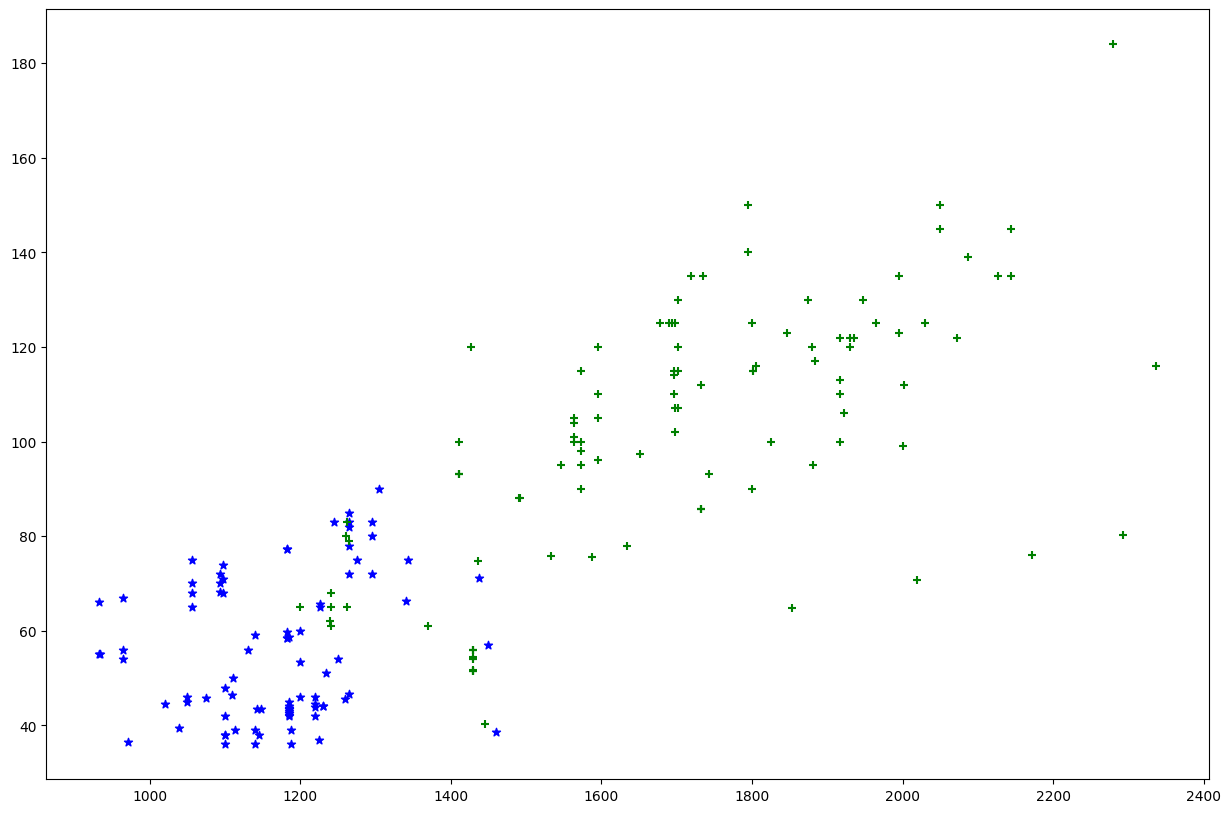

In [31]:
def plot_scatter_location(df1, location):
  bhk2 = df1[(df.location == location) & (df.bhk == 2)]
  bhk3 = df1[(df.location == location) & (df.bhk == 3)]

  plt.figure(figsize=(15, 10))
  plt.scatter(bhk2.total_sqft, bhk2.price, marker = "*", color = "blue", label = "2 bedroom")
  plt.scatter(bhk3.total_sqft, bhk3.price, marker = "+", color = "green", label = "3 bedroom")

  plt.show()

plot_scatter_location(df, "Thanisandra")

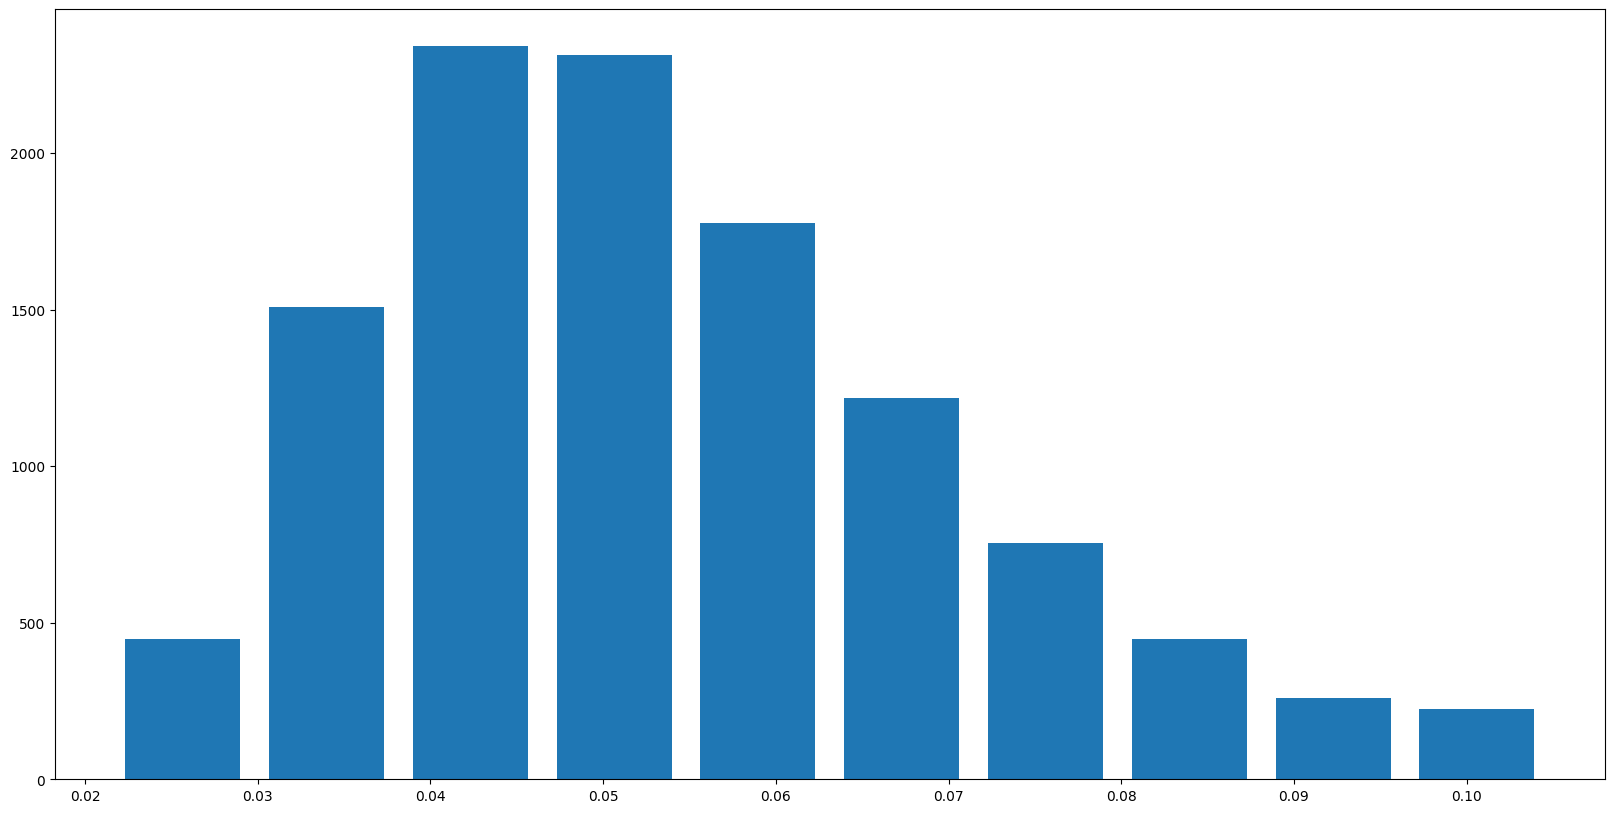

In [32]:
plt.figure(figsize=(20, 10))

plt.hist(df.per_sqft_price, rwidth = 0.8)

plt.show()

In [33]:
df.bath.unique()

array([ 3.,  4.,  5.,  2.,  1.,  8.,  7.,  6.,  9., 10., 12., 16., 13.])

In [34]:
df[df.bath > 10]

,location,total_sqft,bath,price,bhk,per_sqft_price
6121,Neeladri Nagar,4000.0,12.0,160.0,10,0.040000
9695,other,12000.0,12.0,525.0,10,0.043750
9771,other,10000.0,16.0,550.0,16,0.055000
10441,other,6000.0,12.0,150.0,11,0.025000
10745,other,5425.0,13.0,275.0,13,0.050691


In [35]:
df = df[df.bath < df.bhk + 2]

In [36]:
df.shape

(11198, 6)

In [37]:
def remove_bhk_outliers(df):
  exclude_indices = []
  for location, location_df in df.groupby("location"):
    bhk_stats = {}
    for bhk, bhk_df in location_df.groupby("bhk"):
      bhk_stats[bhk] = [
              np.mean(bhk_df["per_sqft_price"]),
              len(bhk_df)
          ]

    for bhk, bhk_df in location_df.groupby("bhk"):
      stats = bhk_stats.get(bhk - 1)
      if stats and stats[1] > 5:
        exclude_indices.extend(bhk_df[bhk_df.per_sqft_price < stats[0]].index.values)
  return df.drop(exclude_indices, axis = "index")

df = remove_bhk_outliers(df)

In [38]:
df.shape

(8010, 6)

In [39]:
dummies = pd.get_dummies(df.location)
df = pd.concat([df.drop("location", axis = "columns"), dummies.drop("other", axis = "columns")], axis = 1)

In [40]:
df.shape

(8010, 244)

## Model building


In [41]:
from sklearn.model_selection import ShuffleSplit, GridSearchCV
from sklearn.linear_model import Lasso, ElasticNet, LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

In [48]:
parameter_grid = {
    "xgb": {
        "model": XGBRegressor(),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
        }
    },
    "lasso": {
        "model": Lasso(),
        "params": {
            "alpha": [0.01, 0.1, 1]
        }
    },
    "ridge": {
        "model": Ridge(),
        "params": {
            "alpha": [0.01, 0.1, 1]
        }
    },
    "elasticnet": {
        "model": ElasticNet(),
        "params": {
            "alpha": [0.01, 0.1, 1],
            "l1_ratio": [0.2, 0.5, 0.8]
        }
    },
    "randomforest": {
        "model": RandomForestRegressor(),
        "params": {
            "n_estimators": [100],
            "max_depth": [5, 10]
        }
    },
    "linear": {
        "model": LinearRegression(),
        "params": {}
    }
}


In [43]:
X, Y = df.drop("price", axis = 1), df.price

In [49]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from joblib import Parallel, delayed


def run_grid_search(model_name, model_params, X, Y):
    gd = GridSearchCV(model_params["model"], model_params["params"], cv=3, n_jobs=-1)
    gd.fit(X, Y)

    return {
        "model_name": model_name,
        "params": gd.best_params_,
        "best_score": gd.best_score_
    }


all_results = Parallel(n_jobs=-1)(
    delayed(run_grid_search)(model_name, parameters, X, Y)
    for model_name, parameters in parameter_grid.items()
)

res = pd.DataFrame(all_results)

In [50]:
res

,model_name,params,best_score
0,xgb,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.943434
1,lasso,{'alpha': 0.01},0.952883
2,ridge,{'alpha': 0.1},0.952735
3,elasticnet,"{'alpha': 0.01, 'l1_ratio': 0.8}",0.827770
4,randomforest,"{'max_depth': 10, 'n_estimators': 100}",0.937056
5,linear,{},0.951315


In [51]:
model = LinearRegression()
model.fit(X, Y)

LinearRegression()

In [52]:
import pickle, json

with open("model.pkl", "wb") as f:
  pickle.dump(model, f)

columns = {
    'data_columns' : [col.lower() for col in X.columns]
}

with open("columns.json","w") as f:
    f.write(json.dumps(columns))